In [1]:
import random
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    set_seed
)

seed = 42
set_seed(seed)
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используется устройство: {device}")

MODEL_NAME = 'answerdotai/ModernBERT-base'


z:\projects\AIE\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Используется устройство: cuda


In [2]:
dataset = load_dataset("emotion")

print("Размер train:", len(dataset["train"]))
print("Размер validation:", len(dataset["validation"]))
print("Размер test:", len(dataset["test"]))

label_names = dataset["train"].features["label"].names
print("Классы эмоций:", label_names)
print("Количество классов:", len(label_names))

for i in range(5):
    example = dataset["train"][i]
    print(f"Текст: {example['text']}")
    print(f"Метка: {example['label']} -> {label_names[example['label']]}")
    print("---")

# В датасете emotion классифицируется эмоциональная окраска текста (англоязычные предложения). Модель должна определить, какую из шести эмоций выражает данное предложение:

# - sadness (грусть)
# - joy (радость)
# - love (любовь)
# - anger (гнев)
# - fear (страх)
# - surprise (удивление)

# Таким образом, задача — многоклассовая классификация эмоций по тексту.

Размер train: 16000
Размер validation: 2000
Размер test: 2000
Классы эмоций: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
Количество классов: 6
Текст: i didnt feel humiliated
Метка: 0 -> sadness
---
Текст: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
Метка: 0 -> sadness
---
Текст: im grabbing a minute to post i feel greedy wrong
Метка: 3 -> anger
---
Текст: i am ever feeling nostalgic about the fireplace i will know that it is still on the property
Метка: 2 -> love
---
Текст: i am feeling grouchy
Метка: 3 -> anger
---


In [3]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

sample_texts = [
    "I am so happy today!",
    "This makes me very sad and disappointed.",
    "I love this beautiful weather.",
    "I'm really angry about the delay.",
    "The horror movie scared me."
]

for text in sample_texts:
    tokens = tokenizer.tokenize(text)
    ids = tokenizer.encode(text, add_special_tokens=True)
    print(f"Текст: {text}")
    print(f"Токены: {tokens}")
    print(f"input_ids: {ids}")
    print(f"Длина: {len(ids)}")
    print(f"Special tokens: CLS={tokenizer.cls_token}, SEP={tokenizer.sep_token}, PAD={tokenizer.pad_token}")
    print("---")


Текст: I am so happy today!
Токены: ['I', 'Ġam', 'Ġso', 'Ġhappy', 'Ġtoday', '!']
input_ids: [50281, 42, 717, 594, 5211, 3063, 2, 50282]
Длина: 8
Special tokens: CLS=[CLS], SEP=[SEP], PAD=[PAD]
---
Текст: This makes me very sad and disappointed.
Токены: ['This', 'Ġmakes', 'Ġme', 'Ġvery', 'Ġsad', 'Ġand', 'Ġdisappointed', '.']
input_ids: [50281, 1552, 2789, 479, 1077, 8872, 285, 19271, 15, 50282]
Длина: 10
Special tokens: CLS=[CLS], SEP=[SEP], PAD=[PAD]
---
Текст: I love this beautiful weather.
Токены: ['I', 'Ġlove', 'Ġthis', 'Ġbeautiful', 'Ġweather', '.']
input_ids: [50281, 42, 2389, 436, 5389, 8588, 15, 50282]
Длина: 8
Special tokens: CLS=[CLS], SEP=[SEP], PAD=[PAD]
---
Текст: I'm really angry about the delay.
Токены: ['I', "'m", 'Ġreally', 'Ġangry', 'Ġabout', 'Ġthe', 'Ġdelay', '.']
input_ids: [50281, 42, 1353, 1663, 11790, 670, 253, 5778, 15, 50282]
Длина: 10
Special tokens: CLS=[CLS], SEP=[SEP], PAD=[PAD]
---
Текст: The horror movie scared me.
Токены: ['The', 'Ġhorror', 'Ġmovie', 'Ġsc

In [4]:
encoded = tokenizer(
    sample_texts,
    padding="max_length",
    truncation=True,
    max_length=20,
    return_tensors="pt"
)
print("Форма input_ids:", encoded["input_ids"].shape)
print("Пример input_ids[0]:", encoded["input_ids"][0])
print("attention_mask[0]:", encoded["attention_mask"][0])


Форма input_ids: torch.Size([5, 20])
Пример input_ids[0]: tensor([50281,    42,   717,   594,  5211,  3063,     2, 50282, 50283, 50283,
        50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283, 50283])
attention_mask[0]: tensor([1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])


In [5]:
model_untuned = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_names)
).to(device)

Loading weights: 100%|██████████| 136/136 [00:00<00:00, 6987.85it/s]
ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [6]:
validation_sample = dataset["validation"].select(range(5))
texts_val = [ex["text"] for ex in validation_sample]
true_labels_val = [ex["label"] for ex in validation_sample]

inputs = tokenizer(texts_val, padding=True, truncation=True, max_length=128, return_tensors="pt").to(device)

model_untuned.eval()
with torch.no_grad():
    outputs = model_untuned(**inputs)
    logits = outputs.logits
    preds = torch.argmax(logits, dim=1).cpu().numpy()

print("Предсказания без fine‑tuning (случайная голова):")
for i, text in enumerate(texts_val):
    print(f"Текст: {text}")
    print(f"Истинная эмоция: {label_names[true_labels_val[i]]}")
    print(f"Предсказанная моделью: {label_names[preds[i]]}")
    print("---")

print("Очевидно, что без дообучения модель не решает задачу классификации эмоций — предсказания практически случайны. Это нормально, потому что голова классификатора не обучена.")


Предсказания без fine‑tuning (случайная голова):
Текст: im feeling quite sad and sorry for myself but ill snap out of it soon
Истинная эмоция: sadness
Предсказанная моделью: surprise
---
Текст: i feel like i am still looking at a blank canvas blank pieces of paper
Истинная эмоция: sadness
Предсказанная моделью: surprise
---
Текст: i feel like a faithful servant
Истинная эмоция: love
Предсказанная моделью: surprise
---
Текст: i am just feeling cranky and blue
Истинная эмоция: anger
Предсказанная моделью: anger
---
Текст: i can have for a treat or if i am feeling festive
Истинная эмоция: joy
Предсказанная моделью: anger
---
Очевидно, что без дообучения модель не решает задачу классификации эмоций — предсказания практически случайны. Это нормально, потому что голова классификатора не обучена.


In [7]:
# Очевидно, что без дообучения модель не решает задачу классификации эмоций — предсказания практически случайны. Это нормально, потому что голова классификатора не обучена.
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

tokenized_dataset = dataset.map(tokenize_function, batched=True)
tokenized_dataset = tokenized_dataset.remove_columns(["text"])
tokenized_dataset = tokenized_dataset.rename_column("label", "labels")
tokenized_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

In [8]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_names)
).to(device)

Loading weights: 100%|██████████| 136/136 [00:00<00:00, 13115.64it/s]
ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [9]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    preds = np.argmax(predictions, axis=1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average="macro")
    return {"accuracy": acc, "f1_macro": f1}


training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    seed=seed,
    report_to="none",
    # disable_tqdm=True,
)

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    group_by_length=True,
    callbacks=[]
)

trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': None, 'bos_token_id': None}.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.483525,0.210676,0.917500,0.887272
2,0.128033,0.148867,0.936000,0.905189
3,0.069968,0.164220,0.938000,0.908410


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.25s/it]


TrainOutput(global_step=3000, training_loss=0.227175417582194, metrics={'train_runtime': 2225.4324, 'train_samples_per_second': 21.569, 'train_steps_per_second': 1.348, 'total_flos': 4089207545856000.0, 'train_loss': 0.227175417582194, 'epoch': 3.0})

In [12]:
from torch.utils.data import DataLoader
from tqdm import tqdm

model.eval()
test_loader = DataLoader(tokenized_dataset["test"], batch_size=32)
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in tqdm(test_loader):
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        preds = torch.argmax(outputs.logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch["labels"].cpu().numpy())

accuracy = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds, average="macro")
print(f"Accuracy: {accuracy:.4f}, F1 macro: {f1:.4f}")

100%|██████████| 63/63 [00:23<00:00,  2.63it/s]


Accuracy: 0.9220, F1 macro: 0.8695


In [13]:
predictions = trainer.predict(tokenized_dataset["test"])
pred_labels = np.argmax(predictions.predictions, axis=1)
true_labels = predictions.label_ids

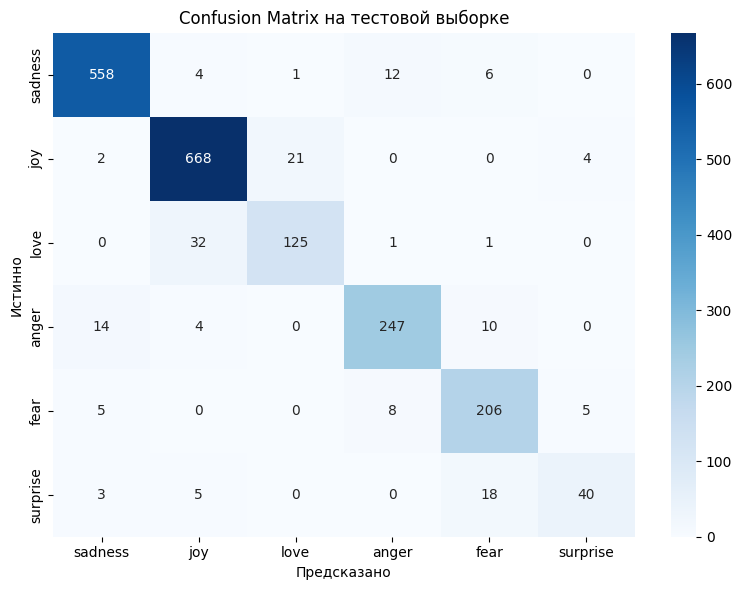

In [18]:
cm = confusion_matrix(true_labels, pred_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_names, yticklabels=label_names)
plt.xlabel("Предсказано")
plt.ylabel("Истинно")
plt.title("Confusion Matrix на тестовой выборке")
plt.tight_layout()
plt.savefig("artifacts/confusion_matrix.png")  # сохраняем артефакт
plt.show()

In [20]:
test_dataset_orig = dataset["test"]
sample_size = min(50, len(test_dataset_orig))
sample_indices = random.sample(range(len(test_dataset_orig)), sample_size)

sample_data = []
for idx in sample_indices:
    text = test_dataset_orig[idx]["text"]
    true = label_names[test_dataset_orig[idx]["label"]]
    pred = label_names[pred_labels[idx]]
    
    logits = predictions.predictions[idx]
    probs = torch.softmax(torch.tensor(logits), dim=0).numpy()
    confidence = np.max(probs)
    sample_data.append({
        "text": text,
        "true_label": true,
        "pred_label": pred,
        "confidence": confidence
    })

df_samples = pd.DataFrame(sample_data)
df_samples.to_csv("artifacts/sample_predictions.csv", index=False)
print("Сохранено sample_predictions.csv")
print(df_samples.head(10))

Сохранено sample_predictions.csv
                                                text true_label pred_label  \
0  im begging fate not to mess with the next cycl...        joy        joy   
1  i receive every month make me proud and feel a...        joy        joy   
2  i feel very naughty to step outside my species...       love       love   
3  i got a shot of terbutaline which makes you fe...       fear       fear   
4  i feel bad for them for wasting their time and...    sadness    sadness   
5  im far ahead than the released tankouban that ...    sadness    sadness   
6  im just now realizing i didnt have a diet coke...        joy        joy   
7  i even dare to try to explain in words how i f...        joy        joy   
8  i am running at an approximate minute pace whi...        joy        joy   
9  i feel like an ungrateful ass a href http this...    sadness    sadness   

   confidence  
0    0.999949  
1    0.999991  
2    0.999674  
3    0.999996  
4    0.999997  
5    0.99994

In [ ]:
errors = df_samples[df_samples["true_label"] != df_samples["pred_label"]]
print(f"Количество ошибок в выборке: {len(errors)} из {len(df_samples)}")
print("\nПримеры ошибок:")
for i, row in errors.head(10).iterrows():
    print(f"Текст: {row['text']}")
    print(f"Истинная эмоция: {row['true_label']} -> Предсказано: {row['pred_label']} (уверенность: {row['confidence']:.3f})")
    print("---")

# На 50 случайных примерах из тестовой выборки модель допустила 4 ошибки (accuracy = 92%). Рассмотрим каждую:

# anger → fear
# Текст: «i feel tortured ... raping and killing chicks»
# Тема насилия вызывает одновременно гнев и страх. Модель выбрала fear с умеренной уверенностью (0.54). Это естественная путаница между негативными эмоциями.

# joy → sadness
# Текст: «i am on so many social networks ... feel pretty talked out»
# Фраза «talked out» (устал от разговоров) имеет негативный оттенок, хотя в контексте может быть нейтральной. Модель ошибочно интерпретировала усталость как грусть.

# joy → love
# Текст: «i feel like one sweet southern mess right now»
# «Sweet» и «mess» в сочетании создают неоднозначность. Модель решила, что это любовь (уверенность 0.59), хотя автор, вероятно, выражает радость от своей «милой неразберихи».

# joy → love
# Текст: «i feel so blessed to be able to share it with you all»
# Благословение и желание поделиться – эмоционально близки к любви. Модель выбрала love с высокой уверенностью (0.78).

Количество ошибок в выборке: 4 из 50

Примеры ошибок:
Текст: i feel tortured delilahlwl am considering i had one the other day about one of my closest friends raping and killing chicks
Истинная эмоция: anger -> Предсказано: fear (уверенность: 0.539)
---
Текст: i am on so many social networks right now and sometimes i feel like that i am pretty talked out
Истинная эмоция: joy -> Предсказано: sadness (уверенность: 0.722)
---
Текст: i just tell people i feel like one sweet southern mess right now
Истинная эмоция: joy -> Предсказано: love (уверенность: 0.593)
---
Текст: i feel so blessed to be able to share it with you all
Истинная эмоция: joy -> Предсказано: love (уверенность: 0.782)
---
